# Study 9: prevalence-as-coherence (no linking function)

A stripped-down variant of `model-study9-vbmc.ipynb` that **bypasses the Beta-mixture linking
function entirely**. Instead of `prevalence ~ pz1*Beta(kl) + (1-pz1)*Beta(nkl)` with 4 free shape
parameters per feature (60 total), the predicted prevalence for a test feature is just the
coherence itself:

$$\hat p_j = \mathrm{pz1}_j = \mathrm{sigmoid}(y_{\text{test},j}).$$

Ratings are scored by a single **Beta observation model centered at the predicted prevalence**,
with one global concentration parameter κ shared across all features:

$$r_{ij} \sim \mathrm{Beta}(\kappa\,\hat p_j,\ \kappa(1-\hat p_j)).$$

So there are **no per-feature nuisance parameters** — only κ (one scalar). This removes the
flexibility that let the GP parameters be unidentifiable: cross-feature differences in prevalence
must now be explained by the coherences (hence by length_scale / mu_0), not absorbed by per-feature
shapes. It's the maximally-identifiable end of the spectrum, and a direct test of whether ls/mu_0
become recoverable when the linking function can't soak up the signal.

In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"

import sys, csv, pickle as pkl
sys.path.insert(0, ".")

import numpy as np
import jax
import jax.numpy as jnp
import blackjax
import matplotlib.pyplot as plt
from scipy.special import logsumexp as scipy_logsumexp
from scipy.special import betainc
from scipy.optimize import minimize_scalar
from pyvbmc import VBMC

from model_jax import make_log_density_fn_joint   # only the GP+utterance sampler; no linking fns

print(f"backend: {jax.default_backend()}")

/opt/miniconda3/envs/compgenerics/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


backend: cpu


In [2]:
with open('../features/set2_features_dataframe.pkl', 'rb') as f:
    df = pkl.load(f)
with open('../../data/study9.csv') as f:
    rows = list(csv.reader(f))
CSV_HEADER = rows[0]
data_rows  = rows[3:]

CSV_TO_FEATURE = {
    'diet_can_eat_spicy_1':  'can eat spicy food',
    'diet_breakfast_late_1': 'eat breakfast very late',
    'diet_five_meals_day_1': 'eat five meals a day',
    'diet_like_juice_pulp_1':'like juice with pulp',
    'diet_pepper_on_all_1':  'put pepper on all their foods',
    'pers_cry_easily_1':     'cry easily',
    'pers_collect_rocks_1':  'like to collect rocks',
    'pers_like_to_dance_1':  'like to dance',
    'pers_like_highfive_1':  'like to give high-fives',
    'pers_read_books_1':     'like to read books',
    'phys_can_roll_tongue_1':'can roll their tongue',
    'phys_can_snap_toes_1':  'can snap with their toes',
    'phys_can_wiggle_ears_1':'can wiggle their ears',
    'phys_cold_hands_feet_1':'have cold hands and feet',
    'phys_snore_sleep_1':    'snore when they sleep',
}
TEST_CSV_COLS = list(CSV_TO_FEATURE.keys())
feat_idx = df.set_index('feature')

train_df = df[df.split == 'train']
x_train  = jnp.array(train_df[['x_2d', 'y_2d']].values)
u_train  = jnp.zeros(len(train_df), dtype=jnp.int32)

test_feature_names = [CSV_TO_FEATURE[c] for c in TEST_CSV_COLS]
x_test = jnp.array([feat_idx.loc[name, ['x_2d', 'y_2d']].values for name in test_feature_names])

col_indices = [CSV_HEADER.index(c) for c in TEST_CSV_COLS]
ratings = []
for row in data_rows:
    try:
        ratings.append([int(row[i]) / 100.0 for i in col_indices])
    except (ValueError, IndexError):
        pass
responses = jnp.array(ratings)
N, J = responses.shape
print(f"x_train: {x_train.shape}, x_test: {x_test.shape}, responses: {responses.shape}")

x_train: (45, 2), x_test: (15, 2), responses: (402, 15)


## Prevalence-as-coherence likelihood

`prevalence_loglik` scores all ratings under `Beta(mean=pz1, concentration=kappa)` using the same
interval (binned) trick as the linking model, so 0/1 and the discrete slider are handled. `fit_kappa`
optimizes the single global concentration (a 1-D solve) — the only nuisance parameter. (You can also
just fix kappa; set `FIT_KAPPA = False`.)

In [3]:
H = 1.0 / 200.0   # half a slider bin

def prevalence_loglik(responses, pz1, kappa):
    """Sum log P(r_ij in its bin) under Beta(mean=pz1_j, conc=kappa). responses (N,J), pz1 (J,)."""
    r = np.asarray(responses, dtype=np.float64)
    p = np.clip(np.asarray(pz1, dtype=np.float64), 1e-4, 1 - 1e-4)   # (J,)
    a = kappa * p                       # (J,)
    b = kappa * (1.0 - p)
    lo = np.clip(r - H, 0.0, 1.0)       # (N,J)
    hi = np.clip(r + H, 0.0, 1.0)
    P  = betainc(a[None, :], b[None, :], hi) - betainc(a[None, :], b[None, :], lo)
    return float(np.sum(np.log(np.maximum(P, 1e-300))))

def fit_kappa(responses, pz1):
    """Best single global concentration kappa for predicted prevalences pz1 (1-D solve)."""
    res = minimize_scalar(lambda lk: -prevalence_loglik(responses, pz1, float(np.exp(lk))),
                          bounds=(np.log(0.5), np.log(500.0)), method='bounded')
    return float(np.exp(res.x))

FIT_KAPPA   = True
KAPPA_FIXED = 4.0   # used only if FIT_KAPPA is False

In [4]:
FIXED_PARAMS = {'output_scale': 1.5, 'beta': 3.0}
N_WARMUP  = 300
N_SAMPLES = 1500
STEP      = 5

eval_count = [0]
eval_log   = []

def log_joint(phi):
    """Log joint P(ratings, theta) using predicted prevalence = coherence (no linking fn)."""
    log_ls, mu_0 = float(phi[0]), float(phi[1])
    length_scale = float(np.exp(log_ls))
    eval_count[0] += 1
    print(f"  eval {eval_count[0]:3d}: ls={length_scale:.3f}  mu_0={mu_0:.3f}", end="  ")

    log_prior_ls  = float(-0.5 * ((log_ls - np.log(0.5)) / 1.5) ** 2)
    log_prior_mu0 = float(-0.5 * mu_0 ** 2)
    log_prior = log_prior_ls + log_prior_mu0

    params = {**FIXED_PARAMS, 'length_scale': length_scale, 'mu_0': mu_0}
    log_density_fn = make_log_density_fn_joint(u_train, x_train, x_test, params)
    init_position = {'training_coherences': jnp.zeros(x_train.shape[0]), 'test_coherences': jnp.zeros(J)}

    rng_key = jax.random.PRNGKey(0)
    rng_key, warmup_key = jax.random.split(rng_key)
    warmup = blackjax.window_adaptation(blackjax.nuts, log_density_fn)
    (state, nuts_params), _ = warmup.run(warmup_key, init_position, num_steps=N_WARMUP)
    nuts = blackjax.nuts(log_density_fn, **nuts_params)

    @jax.jit
    def one_step(state, key):
        return nuts.step(key, state)

    keys = jax.random.split(rng_key, N_SAMPLES)
    tc = []
    for key in keys[:-1]:
        state, _ = one_step(state, key)
        tc.append(np.array(state.position['test_coherences']))
    tc = np.array(tc)

    pz1_draws = np.array(jax.nn.sigmoid(tc[::STEP]))         # (S, J) predicted prevalence per draw
    pz1_bar   = pz1_draws.mean(axis=0)
    kappa     = fit_kappa(responses, pz1_bar) if FIT_KAPPA else KAPPA_FIXED   # 1 global scalar
    log_liks_s = [prevalence_loglik(responses, pz1_draws[s], kappa) for s in range(pz1_draws.shape[0])]

    log_lik   = float(scipy_logsumexp(log_liks_s) - np.log(len(log_liks_s)))
    noise_std = float(np.std(log_liks_s))
    if not np.isfinite(log_lik):
        log_lik, noise_std = -1e6, 1.0

    log_joint_val = float(log_lik + log_prior)
    print(f"kappa={kappa:6.2f}  log_lik={log_lik:.1f}  noise_std={noise_std:.2f}  log_joint={log_joint_val:.1f}")
    eval_log.append((np.array(phi, dtype=float), log_joint_val, noise_std))
    return log_joint_val, noise_std

In [5]:
# pyVBMC varG-squeeze patch (same numpy-compat fix as the linking-function notebook)
import pyvbmc.vbmc.variational_optimization as _vopt
if not getattr(_vopt._gp_log_joint, "_varg_squeeze_patch", False):
    _orig_gp_log_joint = _vopt._gp_log_joint
    def _gp_log_joint_scalar_varg(*args, **kwargs):
        out = list(_orig_gp_log_joint(*args, **kwargs))
        if out[2] is not None:
            out[2] = float(np.squeeze(out[2]))
        return tuple(out)
    _gp_log_joint_scalar_varg._varg_squeeze_patch = True
    _vopt._gp_log_joint = _gp_log_joint_scalar_varg
    print("patched _gp_log_joint (varG squeeze)")

x0  = np.array([np.log(0.4), 0.0])
lb  = np.array([np.log(0.05), -4.0])
ub  = np.array([np.log(20.0),  4.0])
plb = np.array([np.log(0.1), -2.0])
pub = np.array([np.log(5.0),  2.0])
print(f"Start: ls={np.exp(x0[0]):.2f}, mu_0={x0[1]:.2f}")

vbmc = VBMC(log_joint, x0, lb, ub, plb, pub, options={'specify_target_noise': True})
vbmc_result, vbmc_stats = vbmc.optimize()

patched _gp_log_joint (varG squeeze)
Start: ls=0.40, mu_0=0.00
Reshaping x0 to row vector.
Reshaping lower bounds to (1, 2).
Reshaping upper bounds to (1, 2).
Reshaping plausible lower bounds to (1, 2).
Reshaping plausible upper bounds to (1, 2).
Beginning variational optimization assuming NOISY observations of the log-joint
 Iteration  f-count    Mean[ELBO]    Std[ELBO]    sKL-iter[q]   K[q]  Convergence  Action
  eval   1: ls=0.400  mu_0=0.000  kappa=  1.37  log_lik=-27706.1  noise_std=1672.16  log_joint=-27706.2
  eval   2: ls=0.470  mu_0=-1.005  kappa=  1.38  log_lik=-27568.5  noise_std=1388.49  log_joint=-27569.0
  eval   3: ls=0.368  mu_0=-0.393  kappa=  1.38  log_lik=-27679.2  noise_std=1509.82  log_joint=-27679.3
  eval   4: ls=0.569  mu_0=0.283  kappa=  1.35  log_lik=-27576.3  noise_std=1639.43  log_joint=-27576.3
  eval   5: ls=1.276  mu_0=-1.757  kappa=  1.41  log_lik=-27508.2  noise_std=1170.02  log_joint=-27510.0
  eval   6: ls=1.693  mu_0=1.150  kappa=  1.35  log_lik=-275

/opt/miniconda3/envs/compgenerics/lib/python3.11/site-packages/cma/evolution_strategy.py:3379: RuntimeWarning: invalid value encountered in scalar subtract
  current_fitness_range < opts['tolfunrel'] * (es.fit.median0 - es.fit.median_min),
/opt/miniconda3/envs/compgenerics/lib/python3.11/site-packages/cma/evolution_strategy.py:3379: RuntimeWarning: invalid value encountered in scalar multiply
  current_fitness_range < opts['tolfunrel'] * (es.fit.median0 - es.fit.median_min),


  eval 160: ls=1.813  mu_0=-3.960  kappa=  1.39  log_lik=-27545.1  noise_std=665.13  log_joint=-27553.3
    30        160      -27667.61        41.53        14.50        3        377     
  eval 161: ls=2.002  mu_0=-3.537  kappa=  1.39  log_lik=-27553.3  noise_std=809.45  log_joint=-27560.0
  eval 162: ls=18.856  mu_0=-3.822  kappa=  1.39  log_lik=-27657.0  noise_std=542.93  log_joint=-27667.2
  eval 163: ls=17.571  mu_0=-3.986  kappa=  1.41  log_lik=-27613.6  noise_std=165.89  log_joint=-27624.4
  eval 164: ls=18.932  mu_0=-3.998  kappa=  1.41  log_lik=-27551.0  noise_std=314.80  log_joint=-27562.0
  eval 165: ls=3.447  mu_0=-3.992  kappa=  1.40  log_lik=-27559.8  noise_std=125.21  log_joint=-27568.6
    31        165      -27665.86        47.19         3.43        3       97.1     
  eval 166: ls=12.708  mu_0=-3.886  kappa=  1.39  log_lik=-27616.7  noise_std=545.71  log_joint=-27626.6
  eval 167: ls=6.669  mu_0=-3.407  kappa=  1.27  log_lik=-29811.1  noise_std=184.21  log_joint=-2981

## Posterior over (length_scale, mu_0)

Posterior median: ls=1.619  mu_0=-3.973
95% CI ls:  [1.068, 2.397]
95% CI mu_0: [-3.973, -3.972]
convergence: no  (evals 300, ELBO -27534.1)


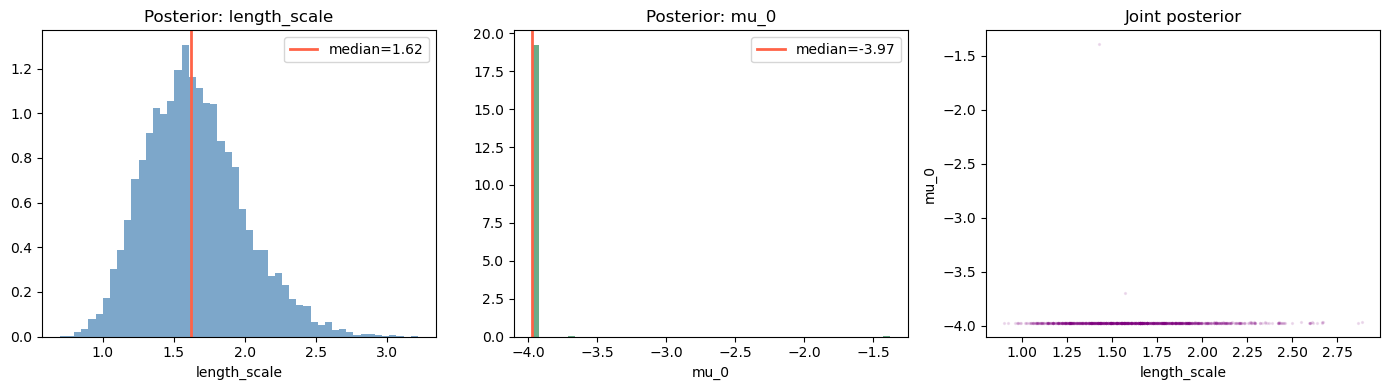

In [6]:
phi_samples, _ = vbmc_result.sample(int(1e4))
ls_samples  = np.exp(phi_samples[:, 0])
mu0_samples = phi_samples[:, 1]
print(f"Posterior median: ls={np.median(ls_samples):.3f}  mu_0={np.median(mu0_samples):.3f}")
print(f"95% CI ls:  [{np.percentile(ls_samples,2.5):.3f}, {np.percentile(ls_samples,97.5):.3f}]")
print(f"95% CI mu_0: [{np.percentile(mu0_samples,2.5):.3f}, {np.percentile(mu0_samples,97.5):.3f}]")
print(f"convergence: {vbmc_stats['convergence_status']}  (evals {vbmc_stats['func_count']}, "
      f"ELBO {vbmc_stats['elbo']:.1f})")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(ls_samples, bins=50, density=True, color='steelblue', alpha=0.7)
axes[0].axvline(np.median(ls_samples), color='tomato', lw=2, label=f'median={np.median(ls_samples):.2f}')
axes[0].set_xlabel('length_scale'); axes[0].set_title('Posterior: length_scale'); axes[0].legend()
axes[1].hist(mu0_samples, bins=50, density=True, color='seagreen', alpha=0.7)
axes[1].axvline(np.median(mu0_samples), color='tomato', lw=2, label=f'median={np.median(mu0_samples):.2f}')
axes[1].set_xlabel('mu_0'); axes[1].set_title('Posterior: mu_0'); axes[1].legend()
axes[2].scatter(ls_samples[::10], mu0_samples[::10], alpha=0.1, s=2, color='purple')
axes[2].set_xlabel('length_scale'); axes[2].set_ylabel('mu_0'); axes[2].set_title('Joint posterior')
plt.tight_layout(); plt.show()

## Forward pass: predicted prevalence (= coherence) vs empirical mean

With no linking function, the model's predicted prevalence is just the posterior-mean coherence
per feature. Compare directly to each feature's empirical mean rating.

Forward pass at posterior mean: ls=1.647, mu_0=-3.971
fitted kappa=1.39   Pearson r(pred, empirical mean)=-0.064


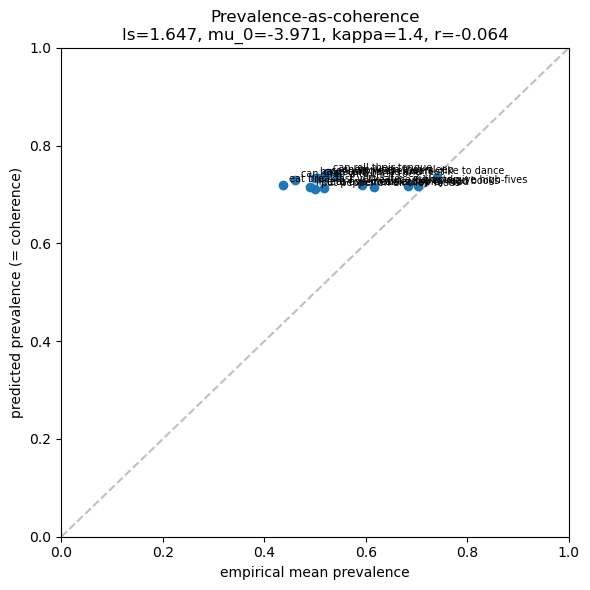

In [7]:
ls_mean, mu0_mean = float(ls_samples.mean()), float(mu0_samples.mean())
print(f"Forward pass at posterior mean: ls={ls_mean:.3f}, mu_0={mu0_mean:.3f}")

params_best = {**FIXED_PARAMS, 'length_scale': ls_mean, 'mu_0': mu0_mean}
log_density_fn = make_log_density_fn_joint(u_train, x_train, x_test, params_best)
init_position = {'training_coherences': jnp.zeros(x_train.shape[0]), 'test_coherences': jnp.zeros(J)}

rng_key = jax.random.PRNGKey(0)
rng_key, warmup_key = jax.random.split(rng_key)
warmup = blackjax.window_adaptation(blackjax.nuts, log_density_fn)
(state, nuts_params), _ = warmup.run(warmup_key, init_position, num_steps=500)
nuts = blackjax.nuts(log_density_fn, **nuts_params)

@jax.jit
def one_step(state, key):
    return nuts.step(key, state)

keys = jax.random.split(rng_key, 2000)
tc = []
for key in keys[:-1]:
    state, _ = one_step(state, key)
    tc.append(np.array(state.position['test_coherences']))
tc = np.array(tc)

pred_prevalence = np.array(jax.nn.sigmoid(tc)).mean(0)         # (J,) predicted = mean coherence
empirical_mean  = np.array(responses.mean(axis=0))
kappa_best      = fit_kappa(responses, pred_prevalence) if FIT_KAPPA else KAPPA_FIXED
corr = np.corrcoef(empirical_mean, pred_prevalence)[0, 1]
print(f"fitted kappa={kappa_best:.2f}   Pearson r(pred, empirical mean)={corr:.3f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(empirical_mean, pred_prevalence, zorder=3)
for j, name in enumerate(test_feature_names):
    ax.annotate(name, (empirical_mean[j], pred_prevalence[j]), fontsize=7,
                xytext=(4, 2), textcoords='offset points')
ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('empirical mean prevalence'); ax.set_ylabel('predicted prevalence (= coherence)')
ax.set_title(f'Prevalence-as-coherence\nls={ls_mean:.3f}, mu_0={mu0_mean:.3f}, kappa={kappa_best:.1f}, r={corr:.3f}')
plt.tight_layout(); plt.show()